In [1]:
# Question 10: Implementing a Custom Clustering Algorithm
# Description: Design and implement a simple custom clustering algorithm using Python for educational purposes.

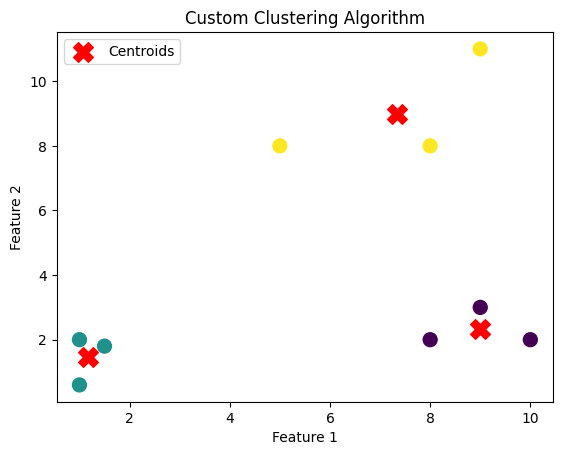

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Synthetic data (2D points)
X = np.array([
    [1, 2], [1.5, 1.8], [5, 8], [8, 8], [1, 0.6], [9, 11],
    [8, 2], [10, 2], [9, 3]
])
def initialize_centroids(X, k):
    indices = np.random.choice(len(X), k, replace=False)
    return X[indices]
def assign_clusters(X, centroids):
    clusters = []
    for x in X:
        distances = np.linalg.norm(x - centroids, axis=1)
        cluster_idx = np.argmin(distances)
        clusters.append(cluster_idx)
    return np.array(clusters)
def update_centroids(X, clusters, k):
    new_centroids = []
    for i in range(k):
        points = X[clusters == i]
        if len(points) == 0:
            # Handle empty cluster by reinitializing a centroid randomly
            new_centroids.append(X[np.random.choice(len(X))])
        else:
            new_centroids.append(points.mean(axis=0))
    return np.array(new_centroids)
def custom_clustering(X, k, max_iters=10):
    centroids = initialize_centroids(X, k)
    for i in range(max_iters):
        clusters = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, clusters, k)
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return clusters, centroids
k = 3
clusters, centroids = custom_clustering(X, k)

plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', s=100)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("Custom Clustering Algorithm")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()
